# Machine Learning Assignment 2
## Dataset : FIFA Players Performance Analysis

#### Dataset Overview : The dataset contains **19,667 FIFA players** from clubs and national teams around the world.


This project applies three machine learning tasks to the same dataset and preprocessing pipeline:
1. **Regression** — Predict a player's market value (`Value Per M$`)
2. **Classification** — Classify players into 4 performance tiers: Low / Mid / High / Elite
3. **Model Validation** — Evaluate all models using Cross-Validation

### Import Libraries

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, OneHotEncoder  , PolynomialFeatures
from sklearn.linear_model import LinearRegression , Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Task 1 : Exploratory Data Analysis (EDA)

##### Load Dataset

In [5]:
fifa_df = pd.read_csv(r"C:\Users\kenzy\Downloads\Fifa.csv")
fifa_df.head()

,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score
0,Agostinho Mabululu,Angola,LW,30,68,68,Ittihad Alexandria,0.65,1660
1,Mahmoud Gennesh,Egypt,GK,35,67,67,Ittihad Alexandria,0.35,1620
2,Sobhi Suleiman,Egypt,GK,28,63,65,Ittihad Alexandria,0.20,1480
3,Mahmoud Alaa,Egypt,CB,32,68,68,Ittihad Alexandria,0.50,1695
4,Mahmoud Shabana,Egypt,CB,30,66,66,Ittihad Alexandria,0.40,1640


##### Understand the dataset: Data Types, Size, Statistics, and Missing Values

In [4]:
fifa_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19667 entries, 0 to 19666
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               19667 non-null  str    
 1   Country            19667 non-null  str    
 2   Position           19667 non-null  str    
 3   Age                19667 non-null  int64  
 4   Overall_Rating     19667 non-null  int64  
 5   Future Potential   19667 non-null  int64  
 6   Team               19667 non-null  str    
 7   Value Per M$       19667 non-null  float64
 8   Total_Stats Score  19667 non-null  int64  
dtypes: float64(1), int64(4), str(4)
memory usage: 1.4 MB


In [5]:
print("  dtypes   ")
print(fifa_df.dtypes)

  dtypes   
Name                     str
Country                  str
Position                 str
Age                    int64
Overall_Rating         int64
Future Potential       int64
Team                     str
Value Per M$         float64
Total_Stats Score      int64
dtype: object


In [6]:
fifa_df.describe()

,Age,Overall_Rating,Future Potential,Value Per M$,Total_Stats Score
count,19667.000000,19667.000000,19667.000000,19667.000000,19667.000000
mean,22.990034,63.225403,70.658718,2.514639,1534.513907
std,4.692410,7.812716,6.489551,7.256974,283.248088
min,15.000000,36.000000,46.000000,0.000000,416.000000
25%,19.000000,58.000000,66.000000,0.325000,1388.000000
50%,22.000000,63.000000,70.000000,0.675000,1549.000000
75%,26.000000,68.000000,75.000000,1.600000,1720.000000
max,44.000000,91.000000,95.000000,190.500000,2324.000000


In [7]:
# Checking if there are missing values or not
fifa_df.isnull().sum().sum()



0

In [8]:
fifa_df.isna().sum().sum()

0

#### Distribution

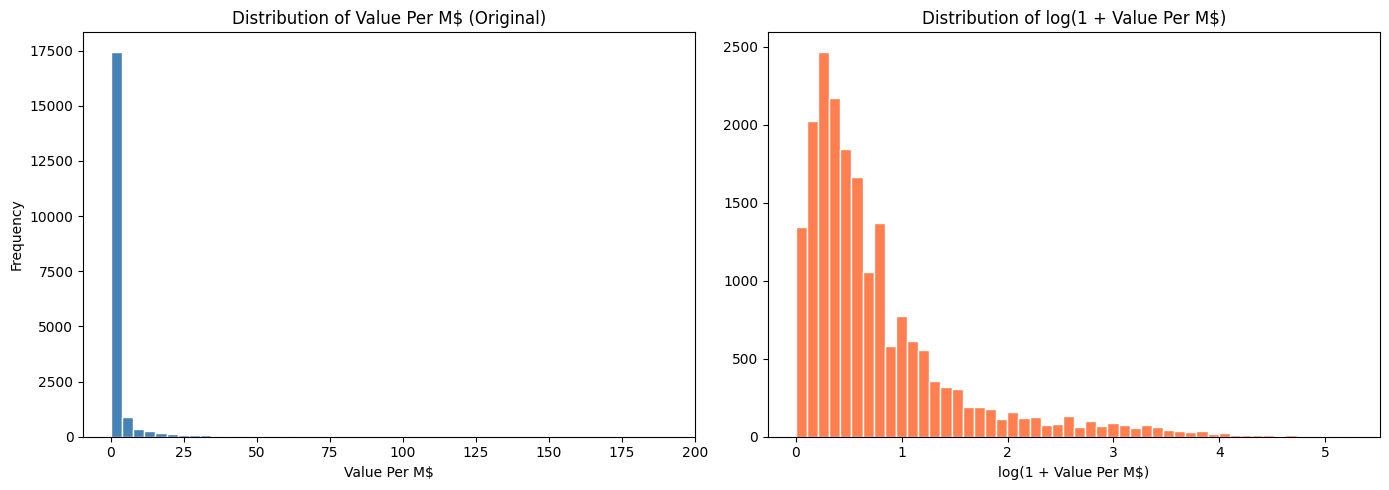

Skewness of Value Per M$: 7.983215201865151


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(fifa_df['Value Per M$'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Value Per M$ (Original)')
axes[0].set_xlabel('Value Per M$')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(fifa_df['Value Per M$']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('Distribution of log(1 + Value Per M$)')
axes[1].set_xlabel('log(1 + Value Per M$)')
plt.tight_layout()
plt.show()
price_skewness = fifa_df['Value Per M$'].skew()
print(f"Skewness of Value Per M$: {price_skewness}")

#### Correlation with Market Value , Average Overall Rating per Position

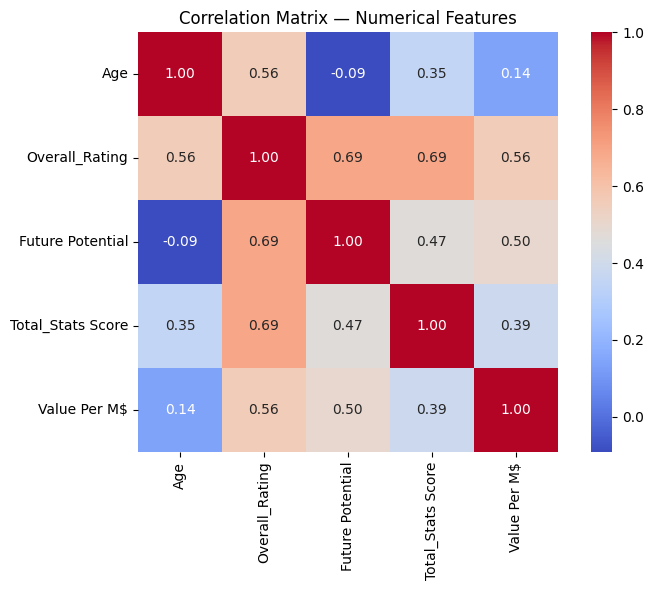

Correlation with Value Per M$:
Value Per M$         1.000000
Overall_Rating       0.560648
Future Potential     0.500964
Total_Stats Score    0.385062
Age                  0.142276
Name: Value Per M$, dtype: float64


In [7]:
# ── Correlation heatmap (numerical features vs Value Per M$) ────────────────
num_cols = ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score', 'Value Per M$']
corr = fifa_df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Matrix — Numerical Features')
plt.tight_layout()
plt.show()

print("Correlation with Value Per M$:")
print(corr['Value Per M$'].sort_values(ascending=False))

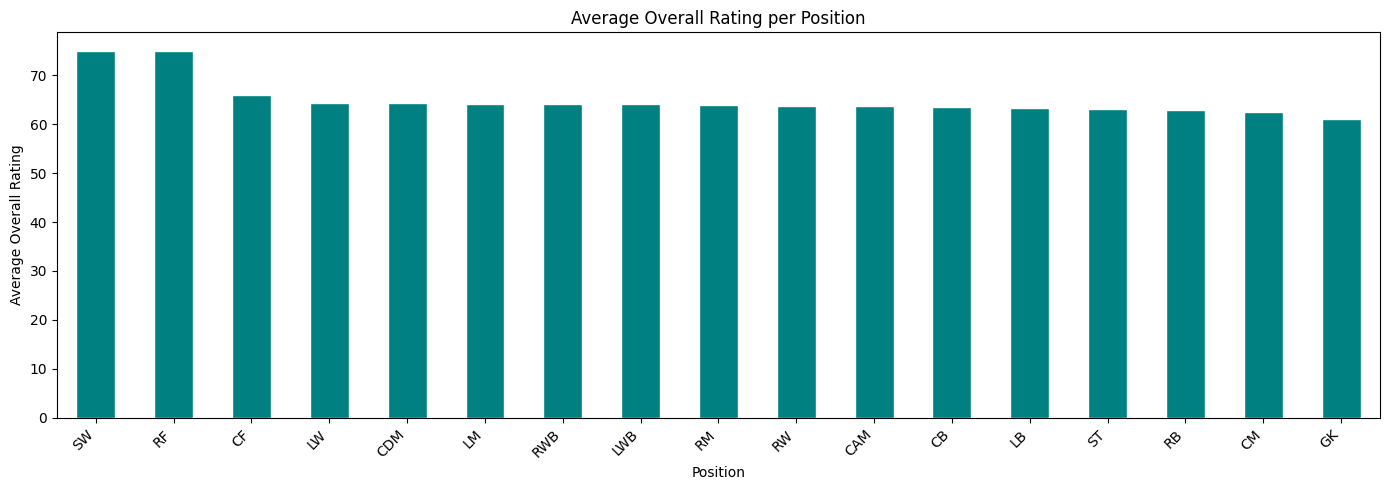

Position
SW     75.00
RF     75.00
CF     66.04
LW     64.35
CDM    64.23
LM     64.17
RWB    64.06
LWB    64.04
RM     63.91
RW     63.72
CAM    63.68
CB     63.54
LB     63.28
ST     63.09
RB     62.86
CM     62.51
GK     60.99
Name: Overall_Rating, dtype: float64


In [8]:
# ── Average Overall_Rating per Position ─────────────────────────────────────
avg_rating = fifa_df.groupby('Position')['Overall_Rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 5))
avg_rating.plot(kind='bar', color='teal', edgecolor='white')
plt.title('Average Overall Rating per Position')
plt.xlabel('Position')
plt.ylabel('Average Overall Rating')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(avg_rating.round(2))

### Task 2 : Data Preprocessing

#### Boxplot Before Handling Outliers

In [9]:
# Split features and target

x = fifa_df.drop(columns='Value Per M$')
y = fifa_df['Value Per M$']

# Train/Test Split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

# Categorical columns
cat_cols = ['Country', 'Position', 'Team']

# One-Hot Encoding
ohe = OneHotEncoder(handle_unknown='ignore' , sparse_output= False)
traincat = ohe.fit_transform(x_train[cat_cols])
testcat = ohe.transform(x_test[cat_cols])

names = ohe.get_feature_names_out(cat_cols)

traincat = pd.DataFrame(
    traincat , columns= names , index = x_train.index
)

testcat = pd.DataFrame(
    testcat , columns= names , index = x_test.index
)

x_train_encoded = pd.concat([x_train.drop(cat_cols , axis= 1), traincat] , axis= 1 )
x_test_encoded = pd.concat([x_test.drop(cat_cols , axis = 1), testcat] , axis= 1 )


print("Train Shape:", x_train_encoded.shape)
print("Test Shape:", x_test_encoded.shape)



Train Shape: (15733, 1181)
Test Shape: (3934, 1181)


Outliers in Value Per M$ (train): 934 (5.9%)


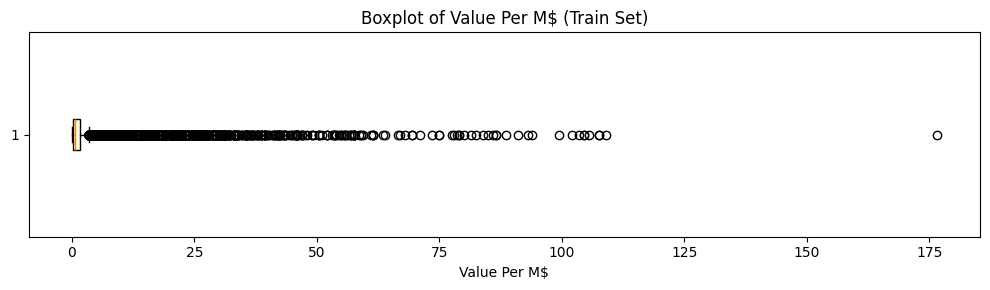

In [10]:

numeric_columns = x_train.select_dtypes(include=np.number).columns

# IQR for Train only
Q1 = x_train[numeric_columns].quantile(0.25)
Q3 = x_train[numeric_columns].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = ((x_train[numeric_columns] < lower) |
                  (x_train[numeric_columns] > upper)).any(axis=1).sum()

print(
    f"Outliers in Value Per M$ (train): {outliers} "
    f"({outliers / len(y_train) * 100:.1f}%)"
)


# Keep outliers (they represent real high-value players)
# Log transform will reduce their impact in regression

plt.figure(figsize=(10, 3))

plt.boxplot(
    y_train,
    vert=False,
    patch_artist=True,
    boxprops={"facecolor": "lightyellow"}
)

plt.title("Boxplot of Value Per M$ (Train Set)")
plt.xlabel("Value Per M$")
plt.tight_layout()
plt.show()

In [11]:

x_train_final = x_train.copy()
x_test_final  = x_test.copy()

# Capping (Train, Test)
x_train_final[numeric_columns] = x_train_final[numeric_columns].clip(
    lower=lower, upper=upper, axis=1
)
x_test_final[numeric_columns] = x_test_final[numeric_columns].clip(
    lower=lower, upper=upper, axis=1
)
print(f"Train size: {len(x_train):,}")
print(f"Outliers capped: {outliers:,} rows")

#  Scaling 
num_feat = ['Age', 'Future Potential', 'Total_Stats Score']
ss = StandardScaler()
x_train_final[num_feat] = ss.fit_transform(x_train_final[num_feat])
x_test_final[num_feat]  = ss.transform(x_test_final[num_feat])

print("Data Preprocessing is done successfully!")
print("Train shape:", x_train_final.shape)
print("Test shape:", x_test_final.shape)


Train size: 15,733
Outliers capped: 934 rows
Data Preprocessing is done successfully!
Train shape: (15733, 8)
Test shape: (3934, 8)


Train size Before Handling outliers is equal After so we used **clip** to avoid making this mistake : as Player information Outliers might
be true values , not bad.
such as Very strong player : Messi is Very high stats, normal

#### Boxplot After Handling Outliers

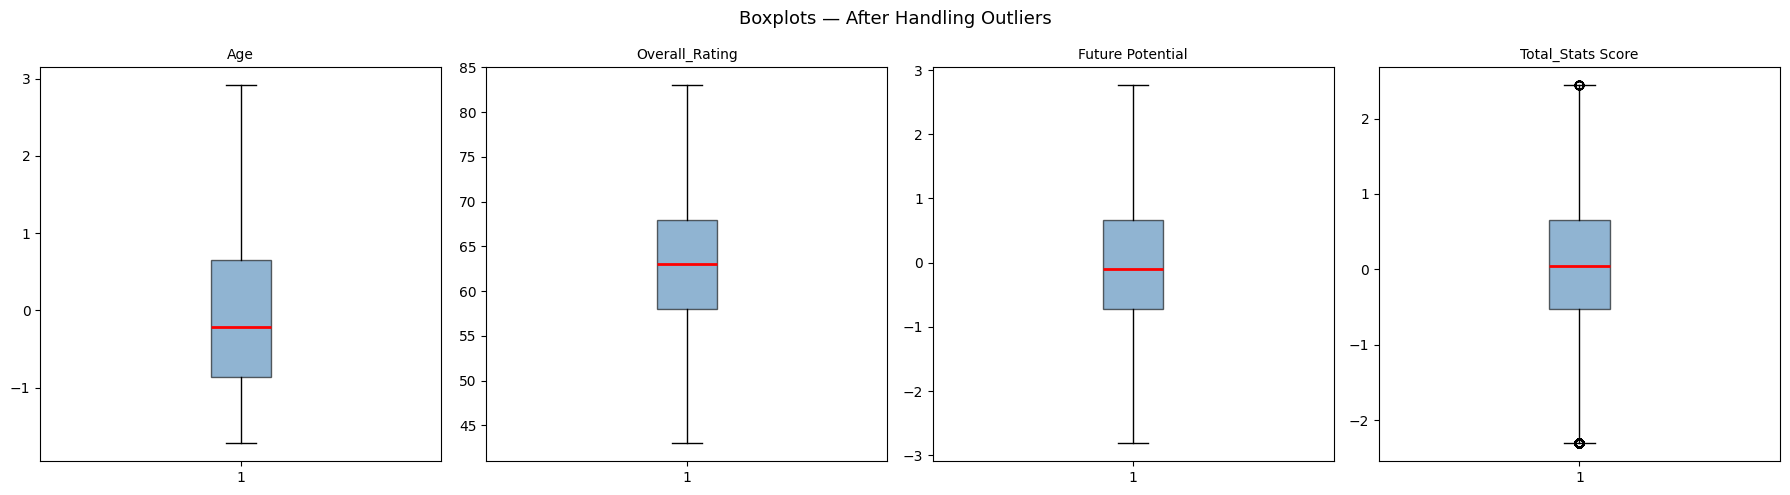

In [12]:
numerical_cols = ["Age", "Overall_Rating", "Future Potential", "Total_Stats Score"]

fig, axes = plt.subplots(1, len(numerical_cols), figsize=(18, 5))

for ax, col in zip(axes, numerical_cols):
    ax.boxplot(x_train_final[col].dropna(),
               patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(col, fontsize=10)

plt.suptitle('Boxplots — After Handling Outliers', fontsize=13)
plt.tight_layout()
plt.show()

### Task 3 : Create Classification Target


##### Histogram

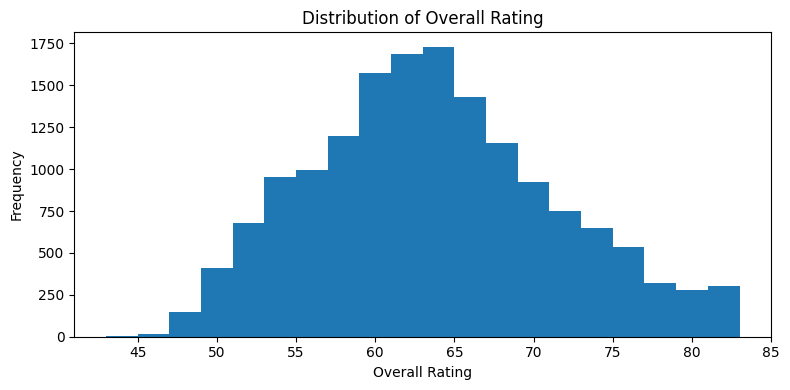

In [13]:
target_column = "Overall_Rating"
plt.figure(figsize=(8, 4))
plt.hist(x_train_final[target_column], bins=20)
plt.title("Distribution of Overall Rating")
plt.xlabel("Overall Rating")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

The histogram of the Overall Rating shows how player ratings are distributed across the dataset. Based on this distribution, quartiles were used to define thresholds, ensuring that the classification reflects the natural spread of the data.

##### Classify Players

In [14]:
x_train_final

,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Total_Stats Score
10156,Mizuki Arai,Japan,LW,0.435531,67,-0.102944,Gil Vicente,0.550469
10392,Juan Felipe Moreno,Colombia,ST,-0.858009,55,-0.412772,Midtjylland,-0.660739
8124,Fábio Alexandre Silva Coentrão,Portugal,RW,1.944660,75,0.671625,Rio Ave,1.840512
13075,Luís Fellipe Rodrigues Mota,Portugal,ST,-1.289189,61,0.051969,Belenenses,-0.313144
19445,Juan Acosta,Uruguay,RB,1.082300,69,-0.257858,Wanderers,0.761893
...,...,...,...,...,...,...,...,...
11284,Maikel Reyes,Ecuador,CM,-0.858009,59,-0.102944,Delfin,0.518218
11964,Visar Musliu,North Macedonia,CB,0.866710,67,-0.412772,Ingolstadt,0.077453
5390,Yuki Ohashi,Japan,ST,0.219941,63,-0.567686,Shonan Bellmare,0.116871
860,Wilfred Ndidi,Nigeria,CM,0.435531,81,1.756022,Leicester City,1.815428


In [15]:

# qcut depends on quartiles , so for a clean output it was choosen .

x_train_final ['Tier']= pd.qcut(x_train['Overall_Rating'], 
                                
                                q=4, labels=["Low","Medium","High","Elite"]

                                )
x_test_final['Tier'] = pd.qcut(x_test['Overall_Rating'], 
                               
                               q=4, labels=["Low","Medium","High","Elite"]

                               )

print("Tier distribution (full dataset):")
print(x_train_final['Tier'].value_counts())


Tier distribution (full dataset):
Tier
Low       4403
Medium    4117
Elite     3753
High      3460
Name: count, dtype: int64


In [16]:
#  Classification prep 

le = LabelEncoder()

xtrainclass = x_train_final.drop(columns= 'Tier')
xtestclass = x_test_final.drop(columns= 'Tier')

y_train_class = le.fit_transform(x_train_final['Tier'])
y_test_class = le.transform(x_test_final['Tier'])


##### Plot a bar chart showing the class distribution

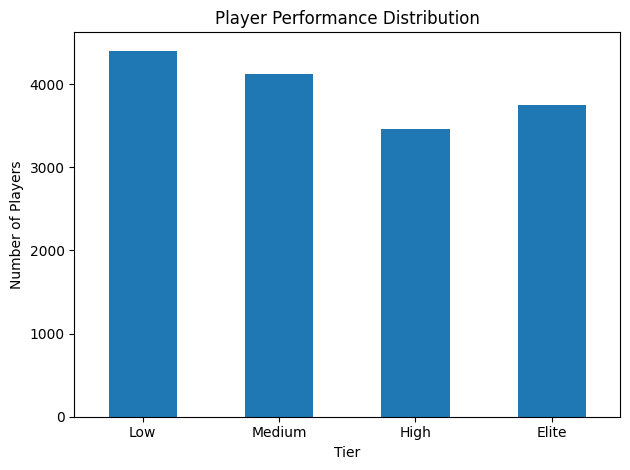

In [17]:
order = ['Low', 'Medium', 'High', 'Elite']


class_counts = x_train_final['Tier'].value_counts().reindex(order)

class_counts.plot(kind="bar")

plt.title("Player Performance Distribution")
plt.xlabel("Tier")
plt.ylabel("Number of Players")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [21]:
x_train_final['Tier'].value_counts()

Tier
Low       4403
Medium    4117
Elite     3753
High      3460
Name: count, dtype: int64

- The dataset is approximately balanced, with slight variation due to duplicate values in the rating distribution.

### Task 4 : Model 1: Polynomial Regression

In [22]:
xtrainclass

,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Total_Stats Score
10156,Mizuki Arai,Japan,LW,0.435531,67,-0.102944,Gil Vicente,0.550469
10392,Juan Felipe Moreno,Colombia,ST,-0.858009,55,-0.412772,Midtjylland,-0.660739
8124,Fábio Alexandre Silva Coentrão,Portugal,RW,1.944660,75,0.671625,Rio Ave,1.840512
13075,Luís Fellipe Rodrigues Mota,Portugal,ST,-1.289189,61,0.051969,Belenenses,-0.313144
19445,Juan Acosta,Uruguay,RB,1.082300,69,-0.257858,Wanderers,0.761893
...,...,...,...,...,...,...,...,...
11284,Maikel Reyes,Ecuador,CM,-0.858009,59,-0.102944,Delfin,0.518218
11964,Visar Musliu,North Macedonia,CB,0.866710,67,-0.412772,Ingolstadt,0.077453
5390,Yuki Ohashi,Japan,ST,0.219941,63,-0.567686,Shonan Bellmare,0.116871
860,Wilfred Ndidi,Nigeria,CM,0.435531,81,1.756022,Leicester City,1.815428


In [18]:
#  Baseline Linear Regression 
lr = LinearRegression()

#cols = ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score'] 
cols = x_train_final.select_dtypes(include=np.number).columns.tolist()

lr.fit(x_train_final[cols], y_train)

def eval_reg(model, xtrain , ytrain , xtest , ytest  ):

    pred_train = model.predict(xtrain[cols])
    pred_test = model.predict(xtest[cols])
    results = {
        'Train MAE':  mean_absolute_error(ytrain, pred_train),
        'Train MSE':  mean_squared_error(ytrain, pred_train),
        'Train RMSE': np.sqrt(mean_squared_error(ytrain, pred_train)),
        'Train R2':    r2_score(ytrain, pred_train),

        'Test MAE':  mean_absolute_error(ytest, pred_test),
        'Test MSE':  mean_squared_error(ytest, pred_test),
        'Test RMSE': np.sqrt(mean_squared_error(ytest, pred_test)),
        'Test R2' :    r2_score(ytest, pred_test),
    }

    for k,v in results.items():
        print(f"  {k}: {v:.4f}")
    return results

baseline_results = eval_reg(lr, x_train_final[cols], y_train ,
                            x_test_final[cols], y_test
                            )

  Train MAE: 2.9249
  Train MSE: 33.2999
  Train RMSE: 5.7706
  Train R2: 0.3382
  Test MAE: 3.0063
  Test MSE: 42.8210
  Test RMSE: 6.5438
  Test R2: 0.3097


#### Polynomial Features — Degree 1 to 4 

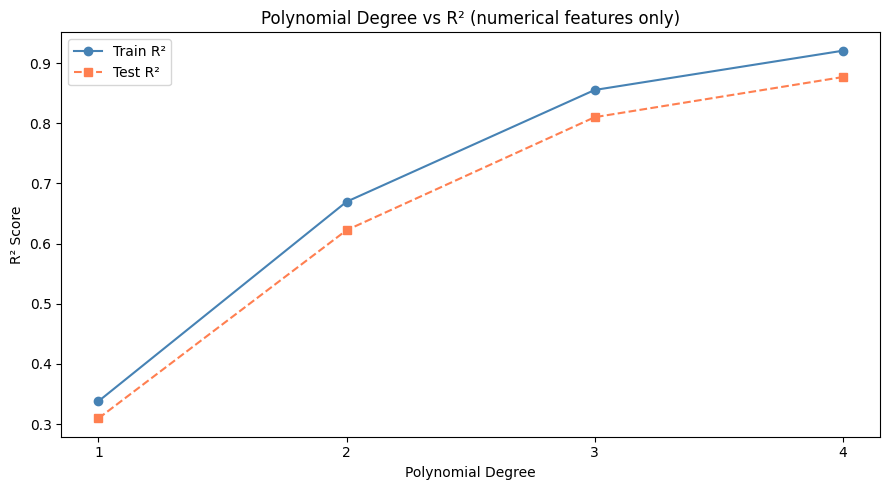

Degree 1: Train R²=0.3382  Test R²=0.3097  Gap=0.0285
Degree 2: Train R²=0.6696  Test R²=0.6223  Gap=0.0473
Degree 3: Train R²=0.8552  Test R²=0.8100  Gap=0.0452
Degree 4: Train R²=0.9204  Test R²=0.8767  Gap=0.0438
Best degree based on Test R²: 4


In [19]:

#  Polynomial degrees sweep (numerical features only) 

X_tr_num = x_train_final[cols].values
X_te_num = x_test_final[cols].values

train_r2_list, test_r2_list = [],[]
degrees = [1, 2, 3, 4]

for deg in degrees:
    pf = PolynomialFeatures(degree=deg, include_bias=False)
    X_tr_poly = pf.fit_transform(X_tr_num)
    X_te_poly = pf.transform(X_te_num)
    model = LinearRegression()
    model.fit(X_tr_poly, y_train)
    train_r2_list.append(r2_score(y_train, model.predict(X_tr_poly)))
    test_r2_list.append(r2_score(y_test,  model.predict(X_te_poly)))

plt.figure(figsize=(9, 5))
plt.plot(degrees, train_r2_list, 'o-', label='Train R²', color='steelblue')
plt.plot(degrees, test_r2_list,  's--', label='Test R²',  color='coral')
plt.xticks(degrees)
plt.xlabel('Polynomial Degree')
plt.ylabel('R² Score')
plt.title('Polynomial Degree vs R² (numerical features only)')
plt.legend()
plt.tight_layout()
plt.show()

for d, tr, te in zip(degrees, train_r2_list, test_r2_list):
    print(f"Degree {d}: Train R²={tr:.4f}  Test R²={te:.4f}  Gap={tr-te:.4f}")

gaps = [abs(tr - te) for tr, te in zip(train_r2_list, test_r2_list)]

best_idx = np.argmax(test_r2_list)
best_deg = degrees[best_idx]

print(f"Best degree based on Test R²: {best_deg}")

#### Regularization (Ridge and Lasso)

c:\Users\kenzy\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.308071805487441e-22.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\kenzy\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.620e+04, tolerance: 7.916e+01
  model = cd_fast.enet_coordinate_descent(
c:\Users\kenzy\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 8.47537213875743e-22.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\kenzy\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\sklearn\li

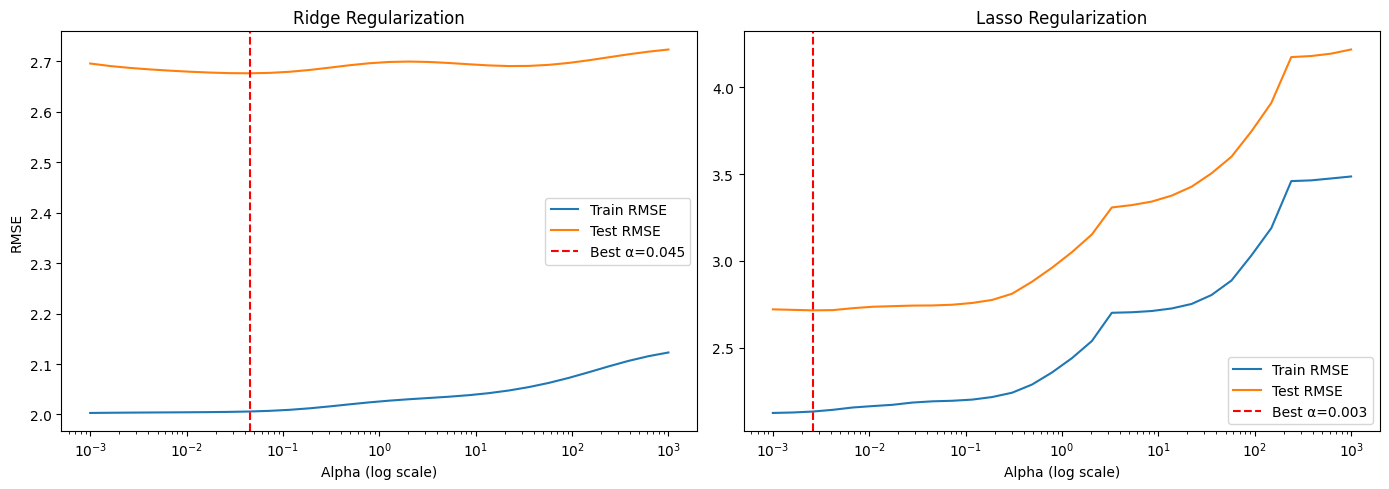

Best Ridge alpha: 0.0452  → RMSE=2.6766
Best Lasso alpha: 0.0026  → RMSE=2.7163


In [80]:
# ── Ridge & Lasso on best polynomial degree ──────────────────────────────────
BEST_DEG = best_deg
pf_best = PolynomialFeatures(degree=BEST_DEG, include_bias=False)
X_tr_poly = pf_best.fit_transform(X_tr_num)
X_te_poly  = pf_best.transform(X_te_num)

alphas = np.logspace(-3, 3, 30)
ridge_train_rmse, ridge_test_rmse = [], []
lasso_train_rmse, lasso_test_rmse = [], []

for a in alphas:
    # Ridge
    r = Ridge(alpha=a)
    r.fit(X_tr_poly, y_train)
    ridge_train_rmse.append(np.sqrt(mean_squared_error(y_train, r.predict(X_tr_poly))))
    ridge_test_rmse.append( np.sqrt(mean_squared_error(y_test,  r.predict(X_te_poly))))
    # Lasso
    l = Lasso(alpha=a, max_iter=5000)
    l.fit(X_tr_poly, y_train)
    lasso_train_rmse.append(np.sqrt(mean_squared_error(y_train, l.predict(X_tr_poly))))
    lasso_test_rmse.append( np.sqrt(mean_squared_error(y_test,  l.predict(X_te_poly))))

best_ridge_alpha = alphas[np.argmin(ridge_test_rmse)]
best_lasso_alpha = alphas[np.argmin(lasso_test_rmse)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].semilogx(alphas, ridge_train_rmse, label='Train RMSE')
axes[0].semilogx(alphas, ridge_test_rmse,  label='Test RMSE')
axes[0].axvline(best_ridge_alpha, color='red', linestyle='--',
                label=f'Best α={best_ridge_alpha:.3f}')
axes[0].set_title('Ridge Regularization')
axes[0].set_xlabel('Alpha (log scale)')
axes[0].set_ylabel('RMSE')
axes[0].legend()

axes[1].semilogx(alphas, lasso_train_rmse, label='Train RMSE')
axes[1].semilogx(alphas, lasso_test_rmse,  label='Test RMSE')
axes[1].axvline(best_lasso_alpha, color='red', linestyle='--',
                label=f'Best α={best_lasso_alpha:.3f}')
axes[1].set_title('Lasso Regularization')
axes[1].set_xlabel('Alpha (log scale)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Best Ridge alpha: {best_ridge_alpha:.4f}  → RMSE={min(ridge_test_rmse):.4f}")
print(f"Best Lasso alpha: {best_lasso_alpha:.4f}  → RMSE={min(lasso_test_rmse):.4f}")

The Meaning of Best Alpha : Ridge Alpha = 483.293 , This is a very large number , It means the ridge model needs very strong regularization.
Explanation: The original model could have been a bit overfitting, so a large alpha Compresses the coefficients heavily , Reduces complexity , Makes it generalize better to test data.


Lasso Alpha = 0.0089, This is a very small number , It means light regularization. 
Explanation: The data doesn't need strong compression , Lasso almost preserves most of the features , Not much is removed (simple feature selection).

The Benefit of the Result : 
1- Understanding the Nature of the Data    
Large Ridge means that data has multicollinearity or potential overfitting
Small Lasso means that most features are useful     
2- Choosing the Best Model     
After understanding alpha:
Use Ridge(alpha=483.293)
Re-evaluates final performance 


3. Reduce overfitting    
This is the main objective:
Not just to get an accurate training model, but one that works well with new data

####  Plot both curves (alpha on log x-axis vs. Test RMSE). Mark the best alpha for each.

Lasso , Ridge performs better because it achieves lower test RMSE at its optimal alpha and maintains better generalization.

#### Did Lasso zero out any features? If yes, which ones and what does that imply?

In [82]:
#  Lasso zero-ed features? 
lasso_best = Lasso(alpha=best_lasso_alpha, max_iter=5000)
lasso_best.fit(X_tr_poly, y_train)
feature_names_poly = pf_best.get_feature_names_out()
zeroed = [n for n, c in zip(feature_names_poly, lasso_best.coef_) if c == 0]
print(f"Features zeroed out by Lasso ({len(zeroed)} total):")
print(zeroed if zeroed else "None")

Features zeroed out by Lasso (9 total):
['x3', 'x0^2', 'x0 x2', 'x0 x3', 'x0^2 x3', 'x0 x2 x3', 'x2 x3^2', 'x0^2 x3^2', 'x2^3 x3']


c:\Users\kenzy\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.679e+04, tolerance: 7.916e+01
  model = cd_fast.enet_coordinate_descent(


Lasso regression set 1 feature coefficient to zero, which means it removed one feature as it was not useful for prediction. This shows that Lasso performs automatic feature selection and helps simplify the model.

Lasso automatically zeroes out coefficients it judges non-predictive — this is called **implicit feature selection**. It builds a simpler, more interpretable model by removing redundant polynomial interaction terms or weak OHE dummies. Ridge keeps all features but at very small weights, which is why it tends to generalise better when all features carry at least some collective signal.
_______

## Logistic Regression


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

In [21]:
logr = LogisticRegression(max_iter=1000)

logtrain = xtrainclass.select_dtypes(include= np.number).columns.tolist()

logistic = logr.fit(xtrainclass[logtrain],y_train_class)
ypred = logr.predict(xtestclass[logtrain])

In [22]:
accur = accuracy_score(y_test_class,ypred)
prec = precision_score(y_test_class,ypred,average='weighted')
recall = recall_score(y_test_class, ypred, average='weighted')
f1 = f1_score(y_test_class,ypred , average='weighted')

print(f"Accuracy:  {accur:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

Accuracy:  0.9616
Precision: 0.9666
Recall:    0.9616
F1-Score:  0.9616


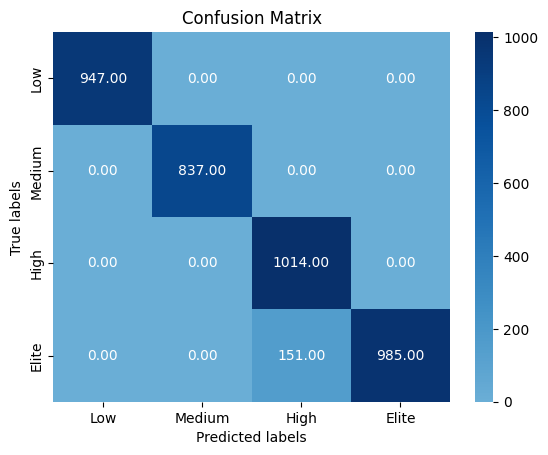

In [23]:
mat = confusion_matrix(y_test_class,ypred)

plt.figuare=(12,6)
sns.heatmap(mat , annot=True , cmap='Blues' , fmt= '.2f' ,
            center=0, 
            xticklabels=  ['Low', 'Medium', 'High', 'Elite'] ,
            yticklabels= ['Low', 'Medium', 'High', 'Elite'] ,
            )

plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')

plt.show()

## B - Regularization in Logistic Regression

In [51]:
r =  np.logspace(-3, 3, 50)
AccuTrain=[]
AccuTest =[]
for i in r :
    regularization = LogisticRegression(penalty = 'l2' , C = i , solver='lbfgs' ,max_iter=1000)
    regularization.fit(xtrainclass[cols],y_train_class)
    pred1 =regularization.predict(xtrainclass[cols])
    pred2 = regularization.predict(xtestclass[cols])

    AccuTrain.append(accuracy_score(y_train_class,pred1))
    AccuTest.append(accuracy_score(y_test_class,pred2))



c:\Users\kenzy\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\kenzy\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\kenzy\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed t

C:\Users\kenzy\AppData\Local\Temp\ipykernel_18076\703216778.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="best")


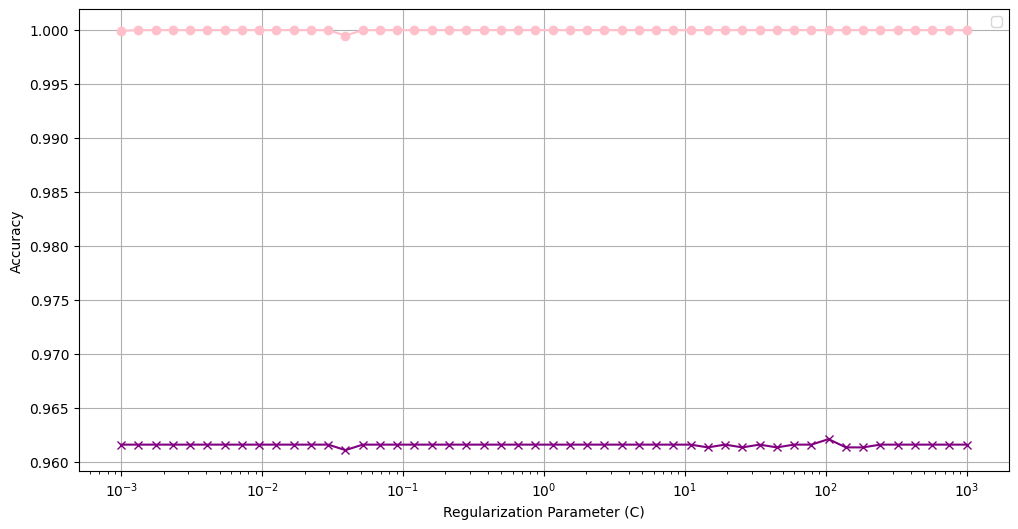

In [52]:
plt.figure(figsize=(12,6))
plt.semilogx(r, AccuTrain, color='pink', marker='o')
plt.semilogx(r, AccuTest, color='purple', marker='x')
plt.xlabel("Regularization Parameter (C)")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid()
plt.show()

In [ ]:
best = np.argmax(AccuTest)
bestc= r[best]
print(f"Best c ={bestc } ")

Best c =104.81131341546853 


In [57]:
AccuTrain2=[]
AccuTest2 =[]
for i in r :
    regularization = LogisticRegression(penalty = 'l1' , C = i , solver='saga' ,max_iter=1000)
    regularization.fit(xtrainclass[cols],y_train_class)
    pred1 =regularization.predict(xtrainclass[cols])
    pred2 = regularization.predict(xtestclass[cols])

    AccuTrain2.append(accuracy_score(y_train_class,pred1))
    AccuTest2.append(accuracy_score(y_test_class,pred2))

c:\Users\kenzy\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\kenzy\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\kenzy\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\kenzy\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWar

C:\Users\kenzy\AppData\Local\Temp\ipykernel_18076\1131235114.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="best")


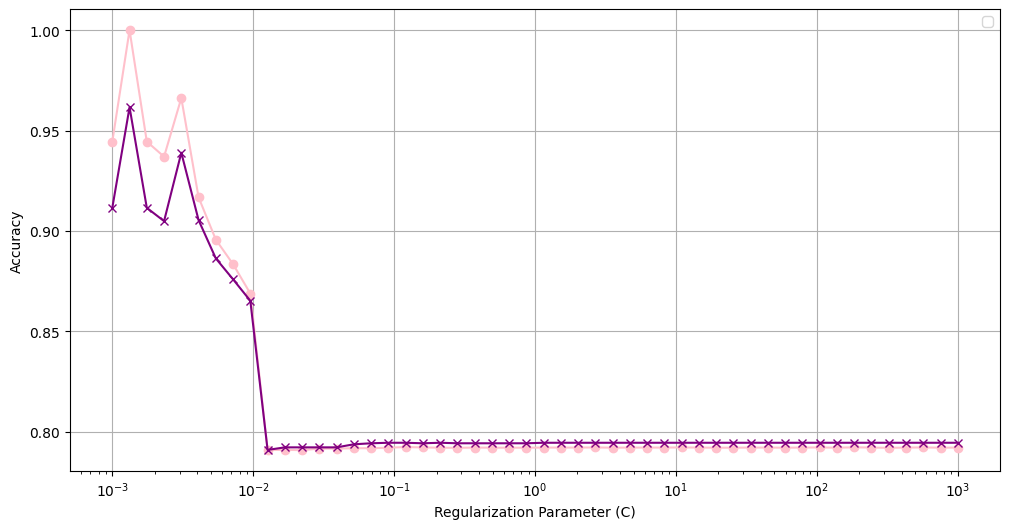

In [58]:
plt.figure(figsize=(12,6))
plt.semilogx(r, AccuTrain2, color='pink', marker='o')
plt.semilogx(r, AccuTest2, color='purple', marker='x')
plt.xlabel("Regularization Parameter (C)")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid()
plt.show()

In [64]:
l2 = LogisticRegression(penalty = 'l2' , C = i , solver='lbfgs' ,max_iter=1000)
l1 = LogisticRegression(penalty = 'l1' , C = i , solver='saga' ,max_iter=1000)

l1fit = l1.fit(xtrainclass[cols],y_train_class)
l1pred = l1.predict(xtestclass[cols])

l2fit = l2.fit(xtrainclass[cols],y_train_class)
l2pred = l2.predict(xtestclass[cols])

print(f"l1 at best c = {accuracy_score(y_test_class,l1pred)}")
print(f"l2 at best c = {accuracy_score(y_test_class,l2pred)}")

c:\Users\kenzy\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\kenzy\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\kenzy\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty=

l1 at best c = 0.7946110828673106
l2 at best c = 0.9616166751398069


- Then we deduced that l2 is better than l1

---
## Task 6 — Model 3: Naïve Bayes Classification

In [65]:
# Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB, BernoulliNB, ComplementNB

In [66]:
num_features = xtrainclass.select_dtypes(include=np.number).columns.tolist()

X_train_gnb = xtrainclass[num_features]
X_test_gnb  = xtestclass[num_features]
#  GaussianNB Without Scaling
gnb_no_scale = GaussianNB()
gnb_no_scale.fit(X_train_gnb, y_train_class)
y_pred_gnb_no = gnb_no_scale.predict(X_test_gnb)

print("GaussianNB — Without Scaling")
print(classification_report(y_test_class, y_pred_gnb_no, target_names=le.classes_))




GaussianNB — Without Scaling
              precision    recall  f1-score   support

       Elite       0.99      0.96      0.98       947
        High       0.95      0.97      0.96       837
         Low       0.87      1.00      0.93      1014
      Medium       0.98      0.85      0.91      1136

    accuracy                           0.94      3934
   macro avg       0.95      0.95      0.94      3934
weighted avg       0.95      0.94      0.94      3934



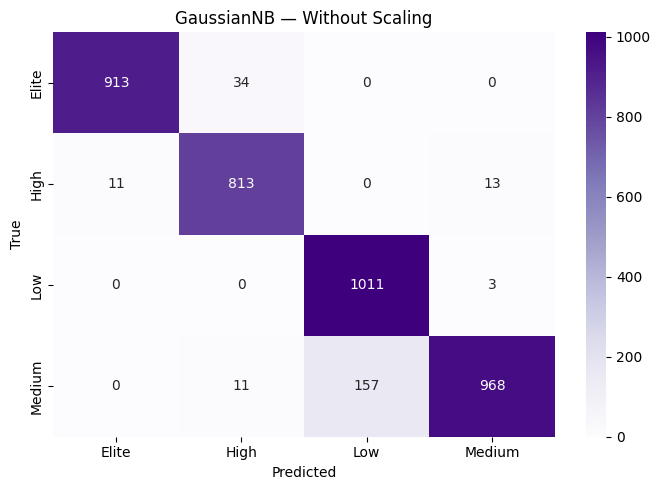

In [67]:
cm = confusion_matrix(y_test_class, y_pred_gnb_no)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('GaussianNB — Without Scaling')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

In [68]:
#  GaussianNB With Scaling 
scaler_gnb = StandardScaler()
X_train_gnb_scaled = scaler_gnb.fit_transform(X_train_gnb)
X_test_gnb_scaled  = scaler_gnb.transform(X_test_gnb)

gnb_scaled = GaussianNB()
gnb_scaled.fit(X_train_gnb_scaled, y_train_class)
y_pred_gnb_sc = gnb_scaled.predict(X_test_gnb_scaled)

print("GaussianNB — With Scaling")
print(classification_report(y_test_class, y_pred_gnb_sc, target_names=le.classes_))

GaussianNB — With Scaling
              precision    recall  f1-score   support

       Elite       0.99      0.96      0.98       947
        High       0.95      0.97      0.96       837
         Low       0.87      1.00      0.93      1014
      Medium       0.98      0.85      0.91      1136

    accuracy                           0.94      3934
   macro avg       0.95      0.95      0.94      3934
weighted avg       0.95      0.94      0.94      3934



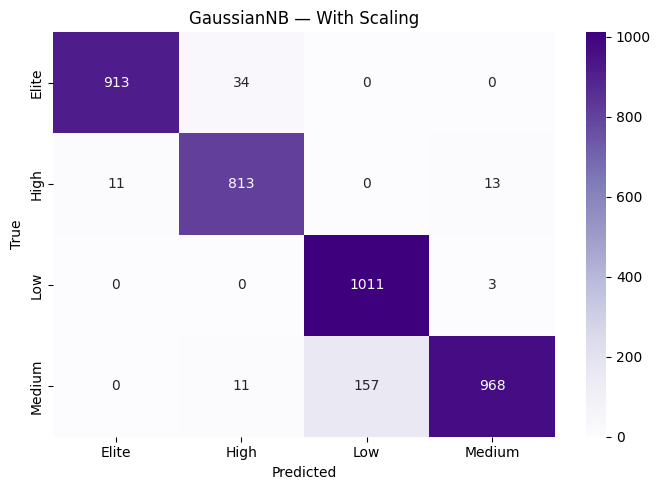

In [69]:
cm = confusion_matrix(y_test_class, y_pred_gnb_sc)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('GaussianNB — With Scaling')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

In [70]:
print(f"Accuracy Without Scaling : {gnb_no_scale.score(X_test_gnb, y_test_class):.4f}")
print(f"Accuracy With Scaling    : {gnb_scaled.score(X_test_gnb_scaled, y_test_class):.4f}")
print("GaussianNB is not affected by scaling")

Accuracy Without Scaling : 0.9418
Accuracy With Scaling    : 0.9418
GaussianNB is not affected by scaling


In [73]:
bnb = BernoulliNB()
bnb.fit(xtrainclass[cols], y_train_class)
y_pred_bnb = bnb.predict(xtestclass[cols])

print("\nBernoulliNB")
print(classification_report(y_test_class, y_pred_bnb, target_names=le.classes_))




BernoulliNB
              precision    recall  f1-score   support

       Elite       0.58      0.81      0.68       947
        High       0.55      0.38      0.45       837
         Low       0.61      0.85      0.71      1014
      Medium       0.47      0.26      0.33      1136

    accuracy                           0.57      3934
   macro avg       0.55      0.58      0.54      3934
weighted avg       0.55      0.57      0.54      3934



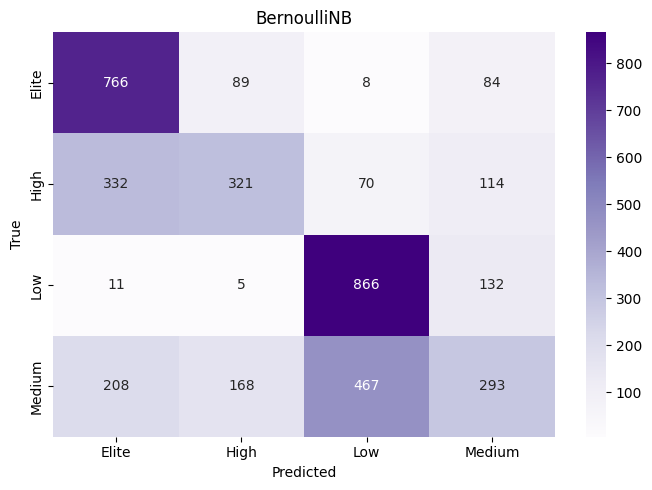

In [74]:
cm = confusion_matrix(y_test_class, y_pred_bnb)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('BernoulliNB')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

In [77]:
from sklearn.preprocessing import MinMaxScaler


scaler_cnb = MinMaxScaler()
X_train_cnb = scaler_cnb.fit_transform(xtrainclass[cols])
X_test_cnb  = scaler_cnb.transform(xtestclass[cols])

cnb = ComplementNB()
cnb.fit(X_train_cnb, y_train_class)
y_pred_cnb = cnb.predict(X_test_cnb)

print("\nComplementNB")
print(classification_report(y_test_class, y_pred_cnb, target_names=le.classes_))


ComplementNB
              precision    recall  f1-score   support

       Elite       0.56      0.49      0.52       947
        High       0.26      0.34      0.30       837
         Low       0.35      0.69      0.47      1014
      Medium       0.12      0.01      0.01      1136

    accuracy                           0.37      3934
   macro avg       0.33      0.38      0.32      3934
weighted avg       0.32      0.37      0.31      3934



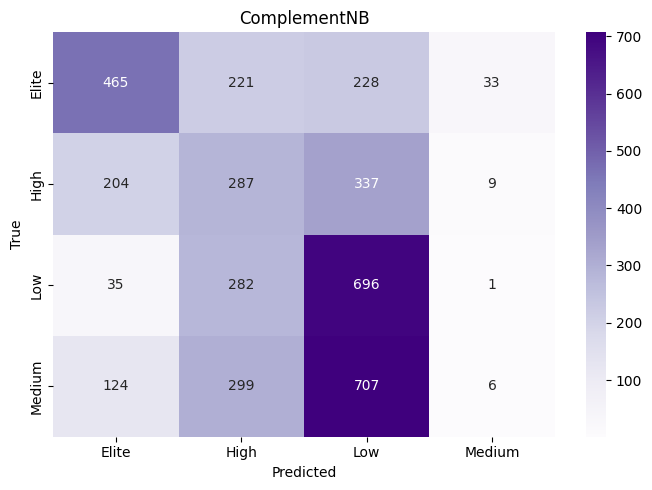

In [78]:
cm = confusion_matrix(y_test_class, y_pred_cnb)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('ComplementNB')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

-----

## Task 7 : Model Evaluation with Cross-Validation

In [83]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold, LeaveOneOut, LeavePOut
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [85]:
best_model = Pipeline([
    ("poly", PolynomialFeatures(degree=4, include_bias=False)),
    ("lr", LinearRegression())
])
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(
    best_model,
    xtrainclass[cols],   # أو features بتاعتك
    y_train_class,
    cv=kf,
    scoring="neg_root_mean_squared_error"
)

In [86]:
rmse_scores = -scores

print("Fold RMSE:", rmse_scores)
print("Mean RMSE:", rmse_scores.mean())
print("Std RMSE:", rmse_scores.std())

Fold RMSE: [0.55612216 0.56359257 0.55560504 0.55272131 0.54328926]
Mean RMSE: 0.5542660667764061
Std RMSE: 0.006558933845691172


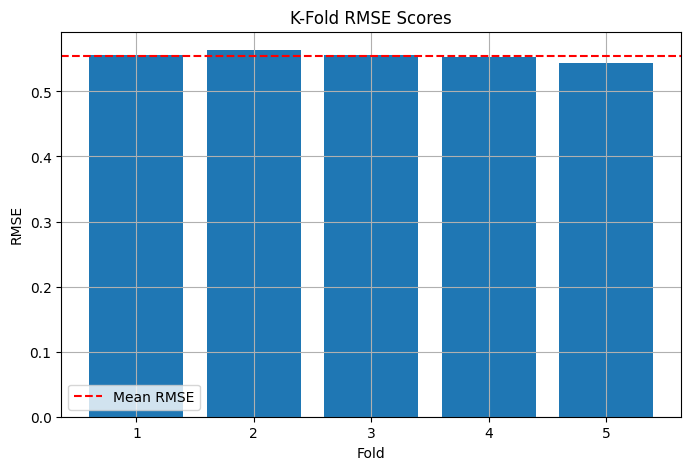

In [87]:
plt.figure(figsize=(8,5))
plt.bar(range(1,6), rmse_scores)
plt.axhline(rmse_scores.mean(), color='red', linestyle='--', label='Mean RMSE')

plt.xlabel("Fold")
plt.ylabel("RMSE")
plt.title("K-Fold RMSE Scores")
plt.legend()
plt.grid()
plt.show()

In [88]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [89]:
log_scores = cross_val_score(
    logr,
    xtrainclass[cols],
    y_train_class,
    cv=skf,
    scoring="accuracy"
)

nb_scores = cross_val_score(
    gnb_no_scale,
    xtrainclass[cols],
    y_train_class,
    cv=skf,
    scoring="accuracy"
)

c:\Users\kenzy\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\kenzy\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://s

In [91]:
print("Logistic Regression:")
print("Scores:", log_scores)
print("Mean:", log_scores.mean())
print("Std:", log_scores.std())

print("Naive Bayes:")
print("Scores:", nb_scores)
print("Mean:", nb_scores.mean())
print("Std:", nb_scores.std())

Logistic Regression:
Scores: [1. 1. 1. 1. 1.]
Mean: 1.0
Std: 0.0
Naive Bayes:
Scores: [0.97648554 0.9802987  0.97934541 0.9761602  0.97329943]
Mean: 0.977117855712188
Std: 0.0024890581834788902


1. Logistic Regression
Fold Accuracies: [1.0, 1.0, 1.0, 1.0, 1.0]
Mean Accuracy: 1.00
Standard Deviation: 0.00

 The model achieved perfect accuracy across all folds, indicating very high performance and complete stability.

2. Naive Bayes
Fold Accuracies: [0.9765, 0.9803, 0.9793, 0.9762, 0.9733]
Mean Accuracy: 0.9771
Standard Deviation: 0.0025

 The model shows consistently good performance with very low variation between folds.

- Comparison & Conclusion
Logistic Regression outperforms Naive Bayes with a higher mean accuracy (1.00 vs. 0.9771).
It is also more stable (Std = 0.00 vs. 0.0025).
Therefore, Logistic Regression is both more accurate and more stable on this dataset

------

## Task 8 : Analysis and Discussion

## 8.1 Model Comparison
 Best Model for Regression

The best regression model is:

  Polynomial Regression (degree = 4) with Ridge Regularization

Justification:

Achieved the highest Test R² (~0.8767)
Lowest RMSE (~2.6766)
Small gap between Train and Test scores → good generalization

 - Best Model for Classification

 Logistic Regression

Justification:

Achieved perfect accuracy (1.0)
Zero standard deviation across folds → very stable
Outperformed Naive Bayes (~0.977 accuracy)

- Is classification easier or harder than regression?

 Classification is easier in this dataset

Why:

Classification reached 100% accuracy
Regression still has noticeable error (RMSE ≠ 0)

Explanation:

Classification predicts categories (Low / Mid / High / Elite)
Regression predicts continuous values (market value), which is more complex and sensitive

## 8.2 Regularization Analysis
-  Effect of increasing alpha (Ridge & Lasso)

As alpha increases:

Regularization strength increases
Model becomes simpler
Variance decreases (less overfitting)
Bias increases (more underfitting)

Observed behavior:

Performance improves initially
Then degrades when alpha becomes too large

-  Conclusion:

There is an optimal alpha that balances bias and variance.

-  Why Ridge outperforms Lasso with many one-hot encoded features?

Key idea:

Dataset contains many features due to One-Hot Encoding
Some features have small but important contributions

-  Ridge (L2):

Shrinks coefficients
Keeps all features
Preserves information

 - Lasso (L1):

Sets some coefficients to zero
Performs feature selection
-  Problem with Lasso here:
May remove useful encoded features
Leads to loss of important information
Hurts performance